# Generative Models

## GANs & VAE

### HW4

**Full Name:** Saeide Danaei

**SID:**  402206907

In this notebook, we are going to implement Variational AutoEncoder (VAE) and Generative Adversarial Network (GAN) on the MNIST dataset. VAEs learn a latent variable model from input data. They sample from this distribution and decode it to generate new data. GANs uses a generator to make images based on a prior distribution.


+ Complete the `TODO` parts in the code accordingly.

In [ ]:
from torch.utils.data import DataLoader, random_split
from torch import optim
from tqdm.notebook import tqdm

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import torchvision.utils as vutils

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Dataset

We will be using MNIST dataset which consists of 60000 data. We split them into train and validation sets, each having 50000 and 10000 data respectively.

In [ ]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
np.random.seed(seed)
# random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
transformation = transforms.Compose([
        transforms.ToTensor(),
    ])

In [ ]:
mnist_data = datasets.MNIST(root='data/', download=True, transform=transformation)

train_data, valid_data = random_split(mnist_data, [50000, 10000])

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 17661812.03it/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 483230.32it/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 4465610.77it/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 10898471.84it/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



In [ ]:
num_threads = 2 # TODO
batch_size = 128 # TODO

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_threads)
val_loader = torch.utils.data.DataLoader(valid_data, batch_size=batch_size, shuffle=False, num_workers=num_threads)

# VAE

Variational Autoencoders (VAEs) are a class of generative models that aim to learn the probability distribution of a given dataset in order to generate new data points that resemble the original data. They use and encoder that embeds each data to a smaller latent space and a decoder that tries to generate the original image, given this latent space.

![](https://upload.wikimedia.org/wikipedia/commons/thumb/4/4a/VAE_Basic.png/425px-VAE_Basic.png)
---


In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()

        ##########################################################
        # TODO
        # Define your variational encoder layers.
        ##########################################################
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU(inplace=True)
        self.fc21 = nn.Linear(hidden_dim, latent_dim)  # Mean of latent space
        self.fc22 = nn.Linear(hidden_dim, latent_dim)  # Log variance of latent space

    def forward(self, x):

        ##########################################################
        # TODO
        # Convert input `x` to mean and log variance of latent
        # space which is then used to sample data for the decoder.
        ##########################################################
        x = self.relu(self.fc1(x))
        z_mean = self.fc21(x)
        z_log_var = self.fc22(x)
        return z_mean, z_log_var

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()

        ##############################
        # TODO
        # Define your decoder layers.
        ##############################

        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.relu = nn.ReLU(inplace=True)
        self.fc4 = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()  # For reconstructing images between 0 and 1

    def forward(self, z):
        ########################################
        # TODO
        # Decode the latent vector `z` to images.
        ########################################

        x = self.relu(self.fc3(z))
        x = self.sigmoid(self.fc4(x))
        return x

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()

        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def reparameterize(self, mean, log_var):
        # Reparameterization trick to ensure gradient flow
        std = torch.exp(0.5 * log_var)  # Standard deviation from log variance
        eps = torch.randn_like(std)  # Random noise with same size as std
        return mean + eps * std

    def forward(self, x):
        ##########################################################
        # TODO
        # Using the encoder and decoder you have defined, encode the
        # image to the latent space and then reconstruct it.
        # Use the eeparameterization trick to ensure gradient flow.
        ##########################################################
        z_mean, z_log_var = self.encoder(x)
        z = self.reparameterize(z_mean, z_log_var)
        reconstructed_x = self.decoder(z)
        return reconstructed_x, z_mean, z_log_var
        return image, z_mean, z_log_var

In [ ]:
def reconstruct_images(vae, images):
    with torch.no_grad():
        recon_images, _, _ = vae(images)
    return recon_images

In [ ]:
def train_vae(dataloader, val_loader, latent_dim, hidden_dim, input_dim, learning_rate=1e-4, num_epochs=100):
  ###############################################
  # TODO
  # Define the loss fc, optimizer and VAE model.
  ###############################################
  model = VAE(input_dim, hidden_dim, latent_dim).to(DEVICE)  # Move model to device (CPU or GPU)
  criterion = nn.BCELoss(reduction='sum')  # Reconstruction loss
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

  sample_images, _ = next(iter(val_loader))
  sample_images = sample_images.view(sample_images.size(0), -1).to(DEVICE)

  recon_images = []

  for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    with tqdm(enumerate(dataloader), total=len(dataloader)) as pbar:
      for i, data in pbar:
        ###############################################
        # TODO
        # Calculate the loss.
        # (optional) Use the KL divergence loss to normalize the
        # output distribution of decoder.
        ###############################################

        images, _ = data
        images = images.view(images.size(0), -1).to(DEVICE)
        optimizer.zero_grad()

        # Forward pass
        recon_batch, z_mean, z_log_var = model(images)
        # Reconstruction loss (use BCE with sigmoid activation)
        reconstruction_loss = criterion(recon_batch, images)
        # KL divergence loss for regularizing latent space
        kl_loss = -0.5 * torch.sum(1 + z_log_var - z_mean.pow(2) - z_log_var.exp())
        loss = reconstruction_loss + kl_loss

        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        pbar.set_description(f'Epoch {epoch+1}/{num_epochs} Loss: {train_loss/(i+1):.4f}')
    print('Loss: {:.4f}'.format(train_loss / len(dataloader.dataset)))
    # TODO
    # Reconstruct `sample_images` and plot first 4 images after each epoch
    # This is used to visualize the progress
    recon_image = reconstruct_images(model, sample_images)
    recon_images.append(recon_image)  # You can store them for later visualization

    # images = images.view(-1, 28, 28)
    recon_image = recon_image.view(-1, 28, 28)
    num_images = 4
    fig, axes = plt.subplots(1, num_images, figsize=(6, 1))
    for i in range(num_images):
        axes[i].imshow(recon_image[i].cpu().numpy(), cmap='gray')
        axes[i].axis('off')
    plt.show()

  return model, recon_images

In [ ]:
input_dim = 28 * 28
hidden_dim = 400
latent_dim = 20
batch_size = 128
epochs = 10
learning_rate = 1e-3

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


  0%|          | 0/391 [00:00<?, ?it/s]

Loss: 171.2462


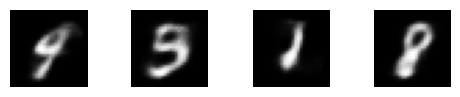

  0%|          | 0/391 [00:00<?, ?it/s]

Loss: 125.0146


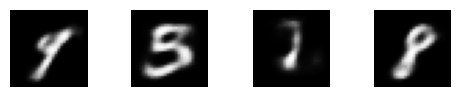

  0%|          | 0/391 [00:00<?, ?it/s]

Loss: 116.4034


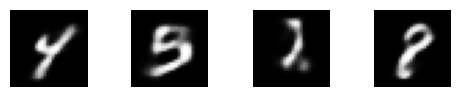

  0%|          | 0/391 [00:00<?, ?it/s]

Loss: 113.0019


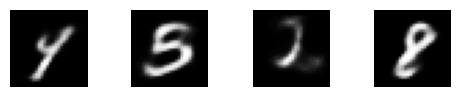

  0%|          | 0/391 [00:00<?, ?it/s]

Loss: 110.9963


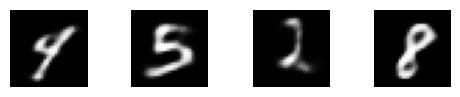

  0%|          | 0/391 [00:00<?, ?it/s]

Loss: 109.5859


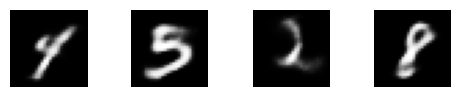

  0%|          | 0/391 [00:00<?, ?it/s]

Loss: 108.6325


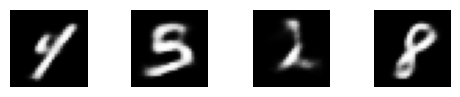

  0%|          | 0/391 [00:00<?, ?it/s]

Loss: 107.9138


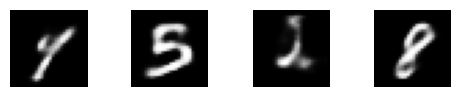

  0%|          | 0/391 [00:00<?, ?it/s]

Loss: 107.3309


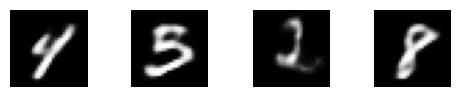

  0%|          | 0/391 [00:00<?, ?it/s]

Loss: 106.8282


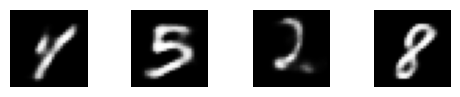

In [ ]:
vae_model, recons_img = train_vae(train_loader, val_loader, latent_dim, hidden_dim, input_dim, learning_rate, epochs)

# Dataset

We will be using MNIST dataset which consists of 60000 data. We split them into train and validation sets, each having 50000 and 10000 data respectively.

In [ ]:
gan_transformation = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])])

In [ ]:
mnist_data_gan = datasets.MNIST(root='data/', download=True, transform=gan_transformation)

g_train_data, g_valid_data = random_split(mnist_data_gan, [50000, 10000])

In [ ]:
num_threads = 2 # TODO
batch_size = 128 # TODO
g_train_loader = torch.utils.data.DataLoader(g_train_data, batch_size=batch_size, shuffle=True, num_workers=num_threads, worker_init_fn=lambda _: np.random.seed(seed))
g_val_loader = torch.utils.data.DataLoader(g_valid_data, batch_size=batch_size, shuffle=False, num_workers=num_threads, worker_init_fn=lambda _: np.random.seed(seed))

# GAN

GANs consist of two models: a generator and a discriminator. The generator creates new data points, and the discriminator evaluates them, trying to distinguish between real and generated (fake) data points. The training process involves updating the generator to produce more realistic data, as judged by the discriminator, and simultaneously updating the discriminator to get better at distinguishing real from fake. This adversarial process leads to improvements in both models, with the generator producing highly realistic data points as a result.

In [ ]:
batch_size = 128
latent_dim = 100
num_epochs = 25
img_shape = (1,28,28)
learning_rate = 3e-4
G_HIDDEN = 32
D_HIDDEN = 32
INPUT_CHANNEL = 1

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim, img_shape):
        super(Generator, self).__init__()

        #######################
        # TODO
        # Define your generator
        #######################

        self.img_shape = img_shape
        self.l1 = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, G_HIDDEN * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(G_HIDDEN * 8),
            nn.ReLU(True),
        )
        self.l2 = nn.Sequential(
            nn.ConvTranspose2d(G_HIDDEN * 8, G_HIDDEN * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(G_HIDDEN * 4),
            nn.ReLU(True),
        )
        self.l3 = nn.Sequential(
            nn.ConvTranspose2d(G_HIDDEN * 4, G_HIDDEN * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(G_HIDDEN * 2),
            nn.ReLU(True),
        )
        self.l4 = nn.Sequential(
            nn.ConvTranspose2d(G_HIDDEN * 2, G_HIDDEN, 4, 2, 1, bias=False),
            nn.BatchNorm2d(G_HIDDEN),
            nn.ReLU(True),
        )

        self.out = nn.Sequential(
            # output layer
            nn.ConvTranspose2d(G_HIDDEN, INPUT_CHANNEL, 3, 1, 3, bias=False),
            nn.Tanh()
        )


    def forward(self, z):
        ##############################################
        # TODO
        # generate an image using `z` vector, sampled
        # from a prior distribution.
        # Reshape the result to the shape of original images
        ##############################################
        x = self.l1(z)
        x = self.l2(x)
        x = self.l3(x)
        x = self.l4(x)
        img = self.out(x)
        return img

class Discriminator(nn.Module):
    def __init__(self, img_dim):
        super(Discriminator, self).__init__()

        ###########################
        # TODO
        # Define your discriminator
        ###########################

        self.l1 = nn.Sequential(
            nn.Conv2d(INPUT_CHANNEL, D_HIDDEN, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.l2 = nn.Sequential(
            nn.Conv2d(D_HIDDEN, D_HIDDEN * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(D_HIDDEN * 2),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.l3 = nn.Sequential(
            nn.Conv2d(D_HIDDEN * 2, D_HIDDEN * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(D_HIDDEN * 4),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.l4 = nn.Sequential(
            nn.Conv2d(D_HIDDEN * 4, D_HIDDEN * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(D_HIDDEN * 8),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(D_HIDDEN * 8, D_HIDDEN * 2),
            nn.BatchNorm1d(D_HIDDEN * 2),
            nn.LeakyReLU(0.2),
            nn.Linear(D_HIDDEN * 2, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        ##############################################
        # TODO
        # Predict whether each image in `img` is real or fake.
        ##############################################
        x = self.l1(img)
        x = self.l2(x)
        x = self.l3(x)
        x = self.l4(x)
        x = self.fc(x)
        x = x.squeeze(1)
        return x

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [ ]:
# Create the generator
gen_net = Generator(latent_dim, img_shape).to(DEVICE)
gen_net.apply(weights_init)
print(gen_net)

# Create the discriminator
disc_net = Discriminator(img_shape).to(DEVICE)
disc_net.apply(weights_init)
print(disc_net)

Generator(
  (l1): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (l2): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (l3): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (l4): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (out): Sequential(
    (0): ConvTranspose2d(32, 

In [ ]:
def train_gan(dataloader, latent_dim, img_shape=(1, 28, 28), learning_rate=3e-4, num_epochs=100):
  ###############################################
  # TODO
  # Define the loss fc, optimizers, generator and discriminator.
  ###############################################
  generator = Generator(latent_dim, img_shape).to(DEVICE).apply(weights_init)
  discriminator = Discriminator(img_shape).to(DEVICE).apply(weights_init)
  adversarial_loss = nn.BCELoss()
  optimizer_G = optim.Adam(generator.parameters(), lr=learning_rate, betas=(0.5, 0.999))
  optimizer_D = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999))
  viz_noise = torch.randn(32, latent_dim, 1, 1, device=DEVICE)
  img_list = []
  G_losses = []
  D_losses = []


  for epoch in range(num_epochs):
    viz_noise_epoch = viz_noise
    with tqdm(enumerate(dataloader), total=len(dataloader)) as pbar:
      for i, (imgs, _) in pbar:
        ##########################################################
        # TODO
        # Calculate the loss for the Generator and the Discriminator.
        ##########################################################
        batch_size = imgs.size(0)
        real_imgs = imgs.to(DEVICE)
        real_labels = torch.ones(batch_size,).to(DEVICE)
        fake_labels = torch.zeros(batch_size,).to(DEVICE)

        # Train Discriminator
        optimizer_D.zero_grad()
        z = torch.randn(batch_size, latent_dim, 1, 1).to(DEVICE)
        fake_imgs = generator(z)
        real_loss = adversarial_loss(discriminator(real_imgs), real_labels)
        fake_loss = adversarial_loss(discriminator(fake_imgs.detach()).view(-1), fake_labels)
        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        g_loss = adversarial_loss(discriminator(fake_imgs).view(-1), real_labels)

        g_loss.backward()
        optimizer_G.step()

        pbar.set_description("[epoch: {}/{}] [D loss: {:.4f}] [G loss: {:.4f}]".format(epoch+1, num_epochs, d_loss.item(), g_loss.item()))


    # Save Losses for plotting later
    G_losses.append(g_loss.item())
    D_losses.append(d_loss.item())

    with torch.no_grad():
        fake = generator(viz_noise_epoch).detach().to(DEVICE)
    img_list.append(vutils.make_grid(fake, padding=2, normalize=True).cpu())

    # TODO
    # Plot generated images after each epoch
    plt.figure(figsize=(10, 10))
    plt.axis("off")
    plt.title(f"Generated Images after Epoch {epoch+1}")
    plt.imshow(np.transpose(img_list[-1], (1, 2, 0)))
    plt.show()

  return generator, discriminator, img_list

  0%|          | 0/391 [00:00<?, ?it/s]

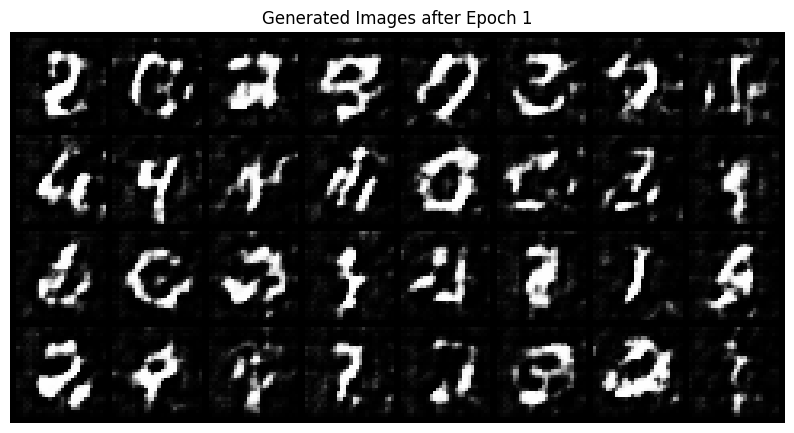

  0%|          | 0/391 [00:00<?, ?it/s]

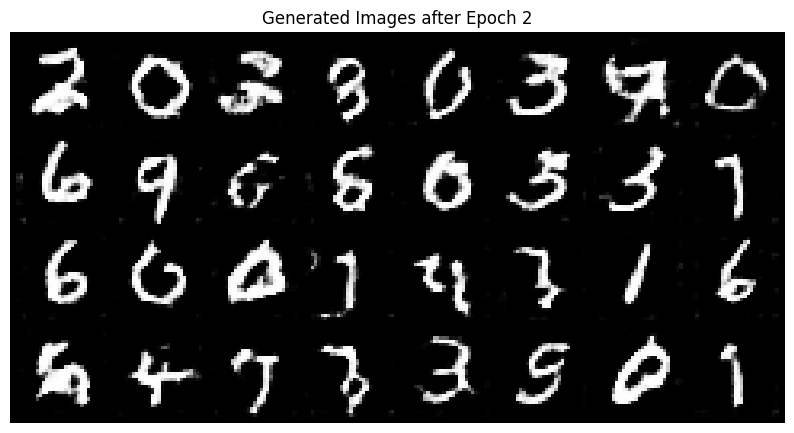

  0%|          | 0/391 [00:00<?, ?it/s]

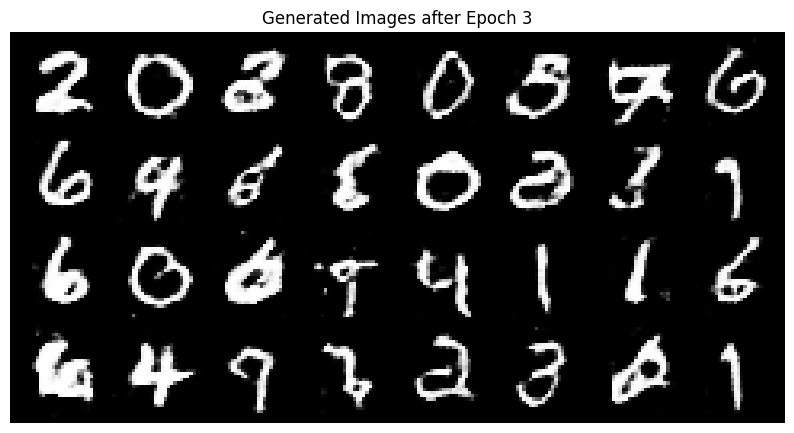

  0%|          | 0/391 [00:00<?, ?it/s]

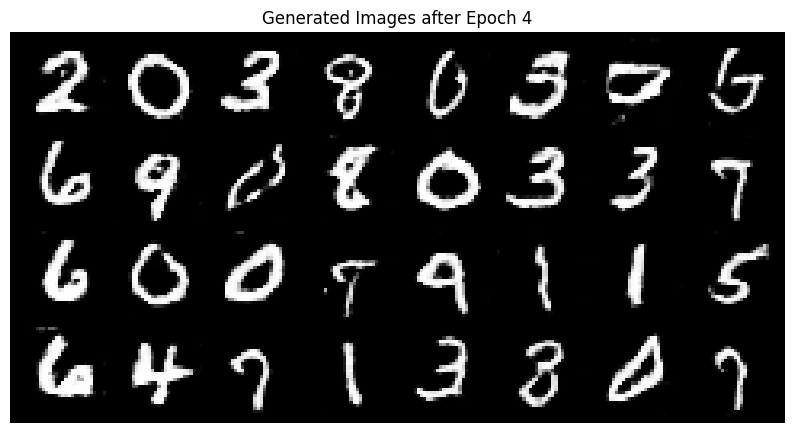

  0%|          | 0/391 [00:00<?, ?it/s]

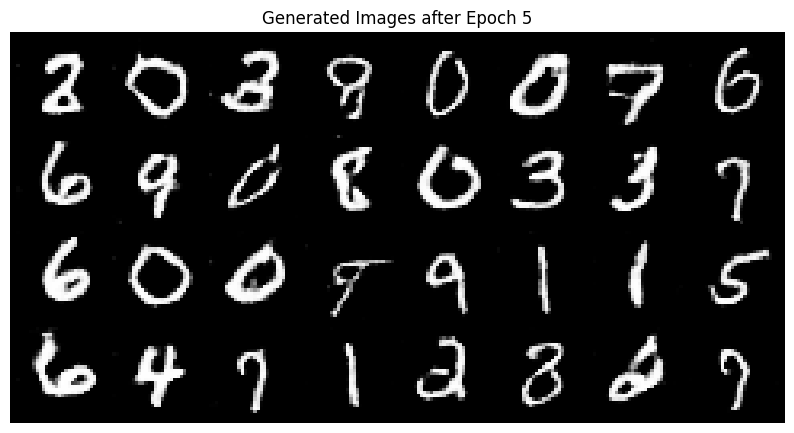

  0%|          | 0/391 [00:00<?, ?it/s]

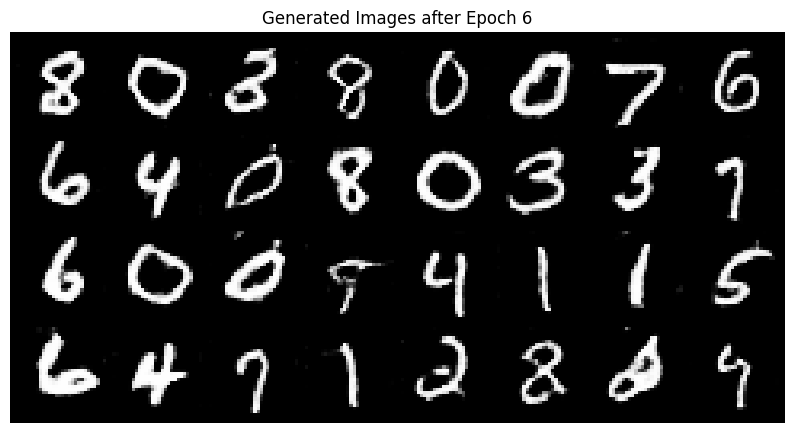

  0%|          | 0/391 [00:00<?, ?it/s]

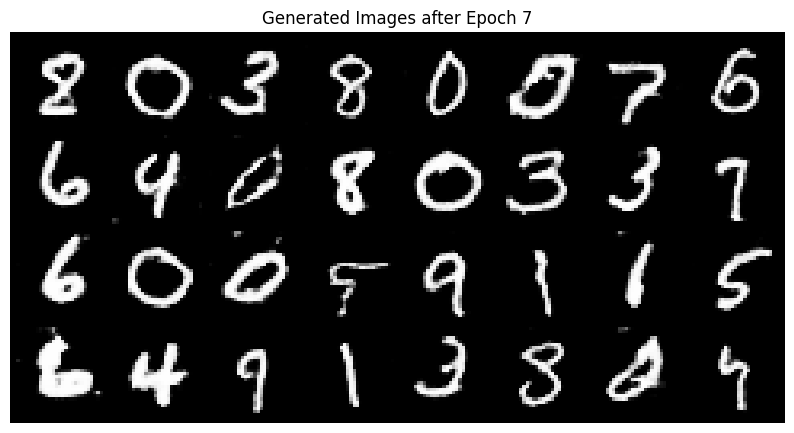

  0%|          | 0/391 [00:00<?, ?it/s]

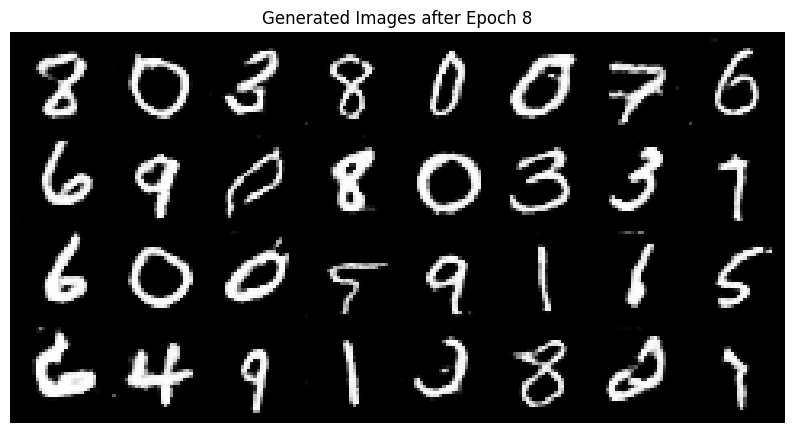

  0%|          | 0/391 [00:00<?, ?it/s]

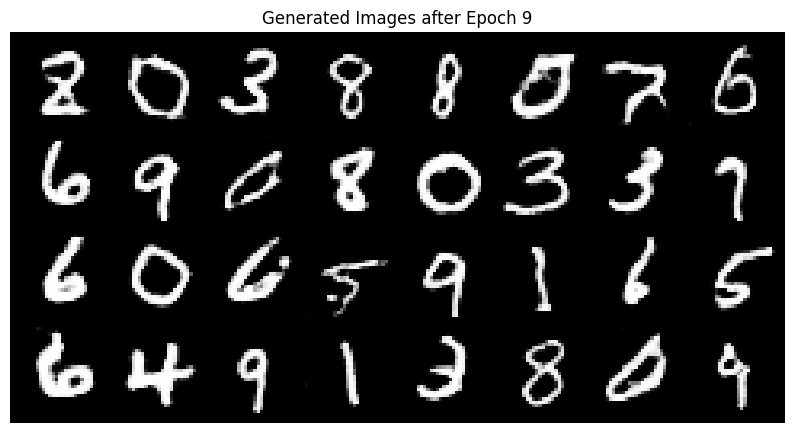

  0%|          | 0/391 [00:00<?, ?it/s]

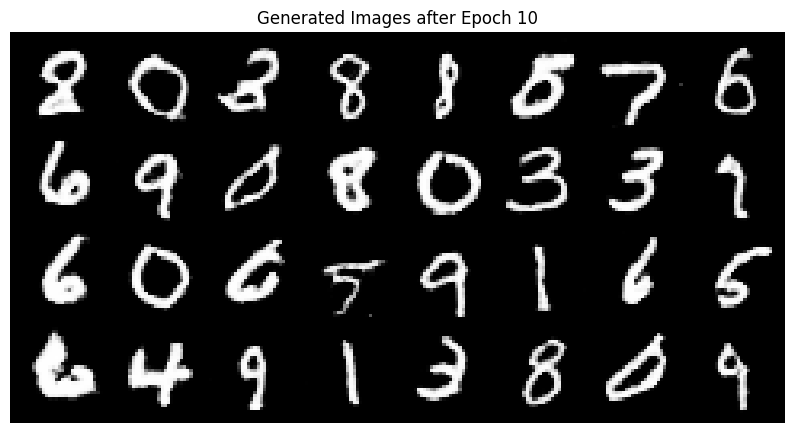

  0%|          | 0/391 [00:00<?, ?it/s]

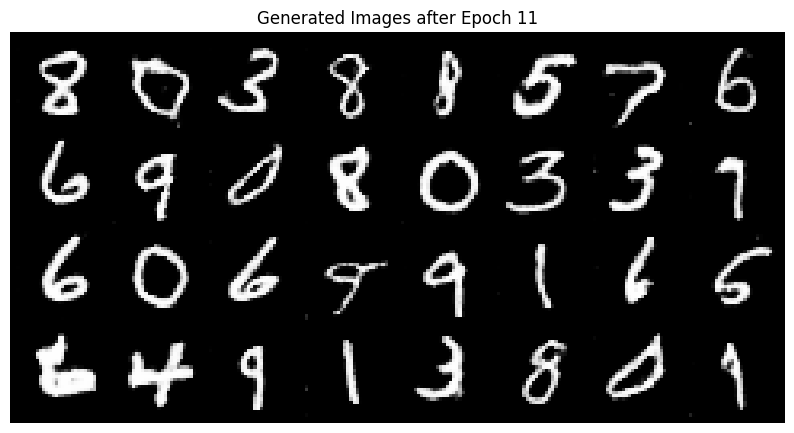

  0%|          | 0/391 [00:00<?, ?it/s]

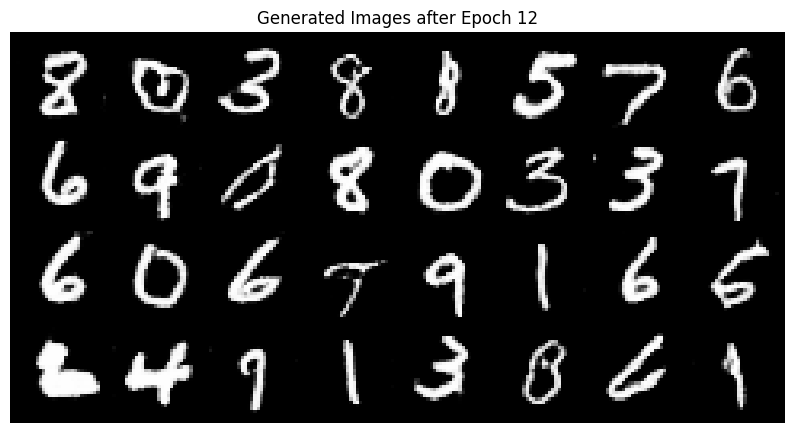

  0%|          | 0/391 [00:00<?, ?it/s]

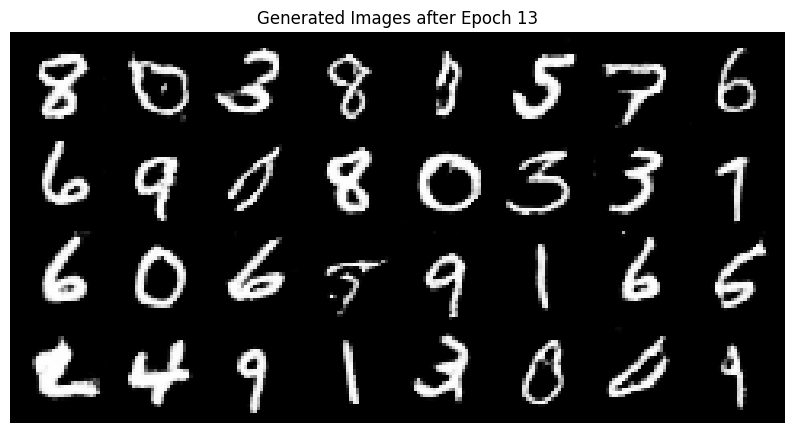

  0%|          | 0/391 [00:00<?, ?it/s]

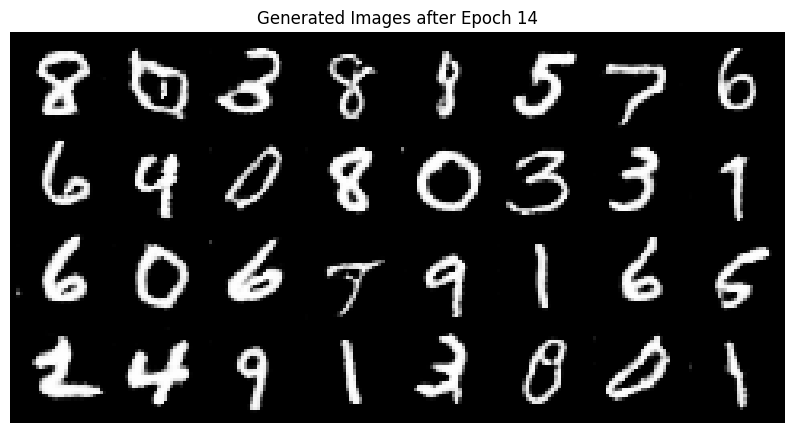

  0%|          | 0/391 [00:00<?, ?it/s]

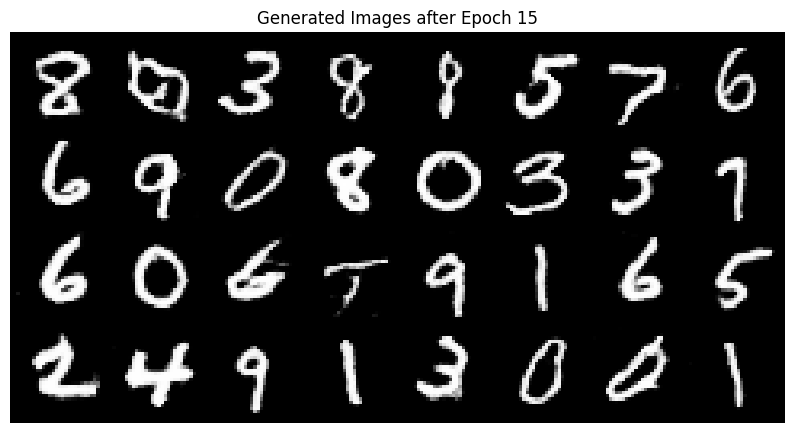

  0%|          | 0/391 [00:00<?, ?it/s]

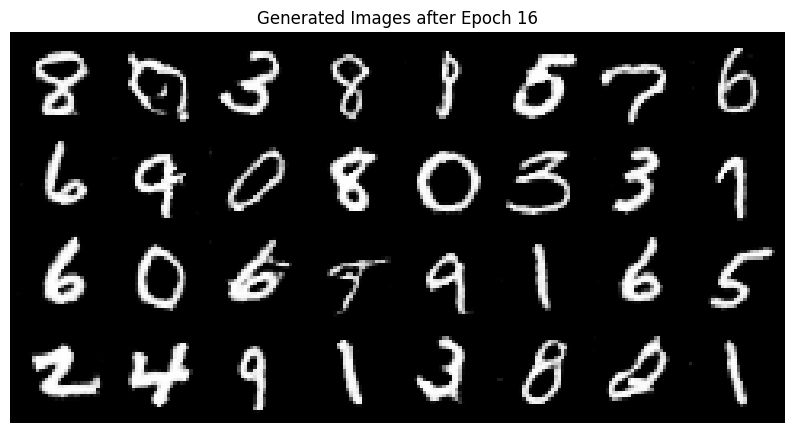

  0%|          | 0/391 [00:00<?, ?it/s]

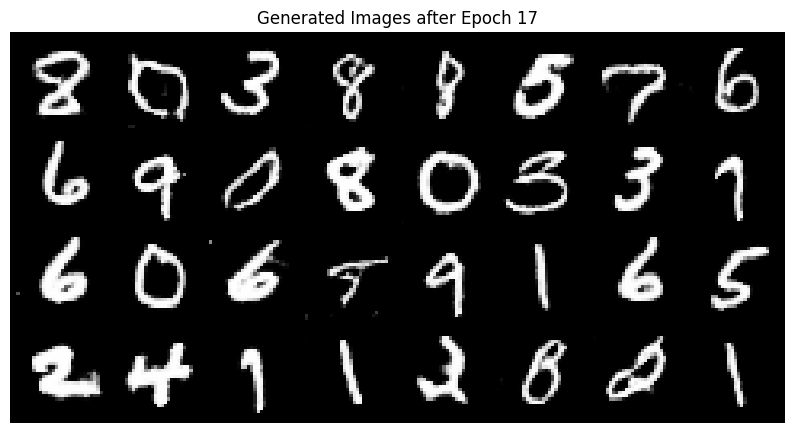

  0%|          | 0/391 [00:00<?, ?it/s]

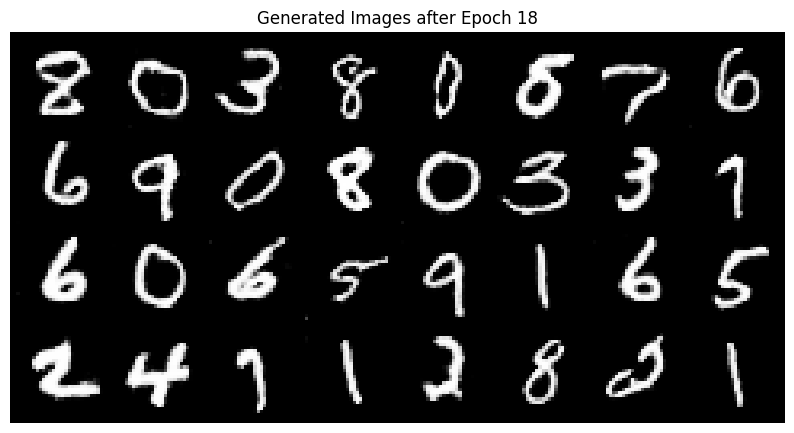

  0%|          | 0/391 [00:00<?, ?it/s]

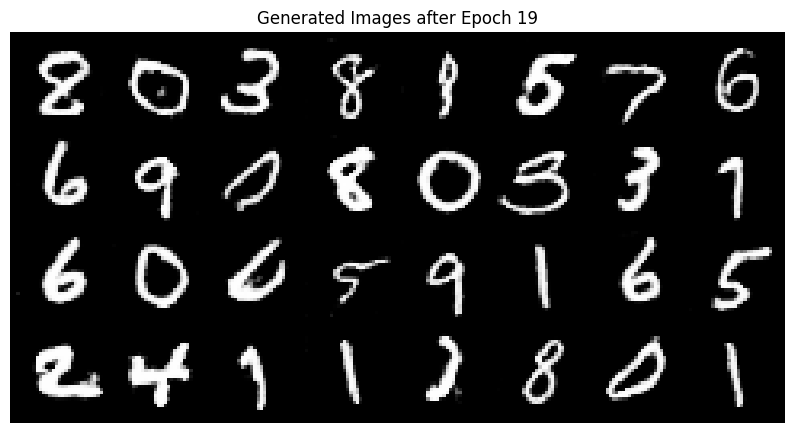

  0%|          | 0/391 [00:00<?, ?it/s]

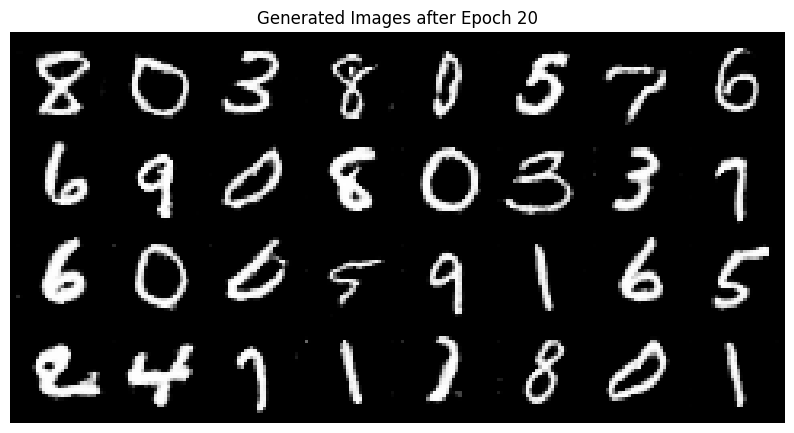

  0%|          | 0/391 [00:00<?, ?it/s]

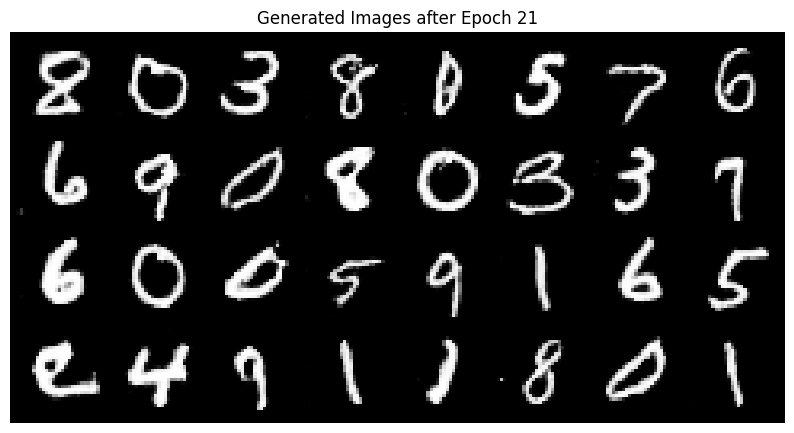

  0%|          | 0/391 [00:00<?, ?it/s]

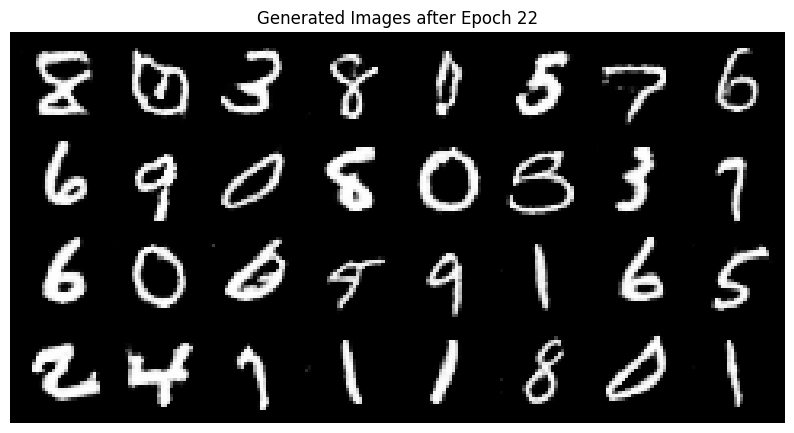

  0%|          | 0/391 [00:00<?, ?it/s]

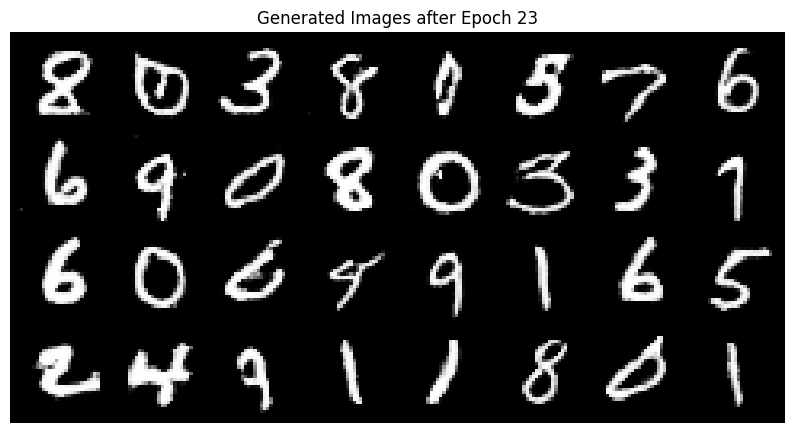

  0%|          | 0/391 [00:00<?, ?it/s]

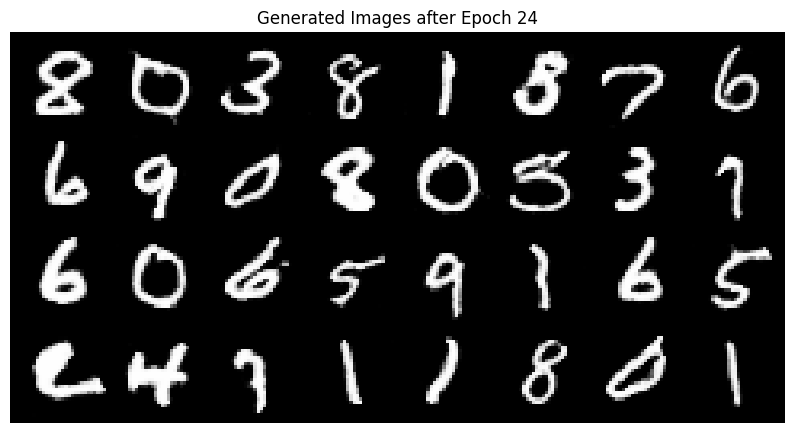

  0%|          | 0/391 [00:00<?, ?it/s]

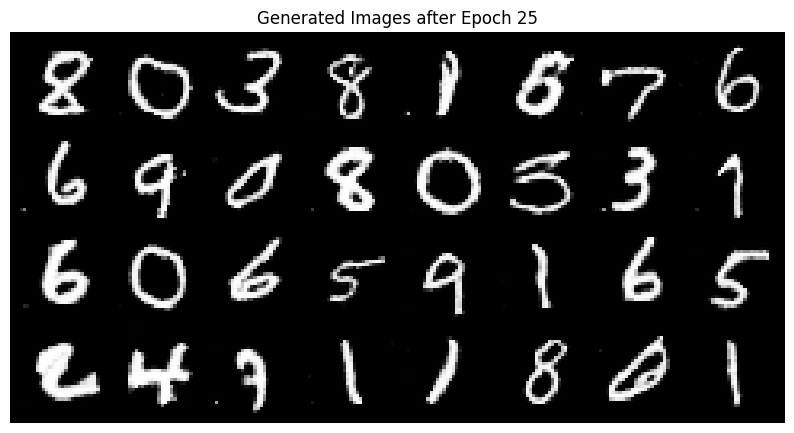

In [ ]:
generator, discriminator, img_list = train_gan(g_train_loader, latent_dim, img_shape=(1, 28, 28), learning_rate=learning_rate, num_epochs=num_epochs)

# Compare

Use validation dataset to plot and compare the results of your trained models.

In [ ]:
# TODO
# Comparison of the generated images
def plot_comparison(vae, gan, dataloader, num_images=8, latent_dim=100):
    vae.eval()
    gan.eval()
    with torch.no_grad():
        # Get real images and VAE reconstructions
        for imgs, _ in dataloader:
            imgs = imgs.cuda()
            recon_imgs = reconstruct_images(vae, imgs)
            break

        # Generate GAN images
        z = torch.randn(num_images, latent_dim, 1, 1).cuda()
        generated_imgs = gan(z)

    # Select images to display
    original_images = imgs[:num_images]
    reconstructed_images = recon_imgs[:num_images]
    generated_images = generated_imgs

    # Plot images
    fig, axes = plt.subplots(3, num_images, figsize=(num_images, 3))
    for i in range(num_images):
        axes[0, i].imshow(original_images[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(reconstructed_images[i].cpu().squeeze(), cmap='gray')
        axes[1, i].axis('off')
        axes[2, i].imshow(generated_images[i].cpu().squeeze(), cmap='gray')
        axes[2, i].axis('off')

    axes[0, 0].set_title('Original')
    axes[1, 0].set_title('Reconstructed (VAE)')
    axes[2, 0].set_title('Generated (GAN)')
    plt.show()

# Plot comparison
plot_comparison(vae_model, generator, val_loader, num_images=8, latent_dim=100)
